# LSTM for Rainfall-Runoff Prediction: Leaf River Catchment

## Motivation

The **rainfall-runoff** problem is one of the oldest challenges in hydrology: given a record of precipitation (and other meteorological forcing), predict streamflow at a catchment outlet. This is hard because:

- Runoff depends on **antecedent moisture** — yesterday's rain affects today's runoff
- Snowmelt, evapotranspiration, and subsurface storage create **multi-week memory**
- The relationships are highly **non-linear** (infiltration, saturation excess)

LSTMs are a natural fit: the cell state can represent soil moisture storage, and the gating mechanism can learn when precipitation runs off immediately vs. when it infiltrates.

## Dataset: Leaf River, Mississippi

We use daily records from the Leaf River catchment — a ~1944 km² basin in southern Mississippi included in many hydrology benchmarks. The CSV contains three columns:

| Column | Units | Description |
|--------|-------|-------------|
| `Precipitation` | mm/day | Basin-average daily rainfall |
| `Temperature` | °C | Mean daily temperature |
| `Streamflow` | mm/day | Observed daily discharge (normalized to basin area) |

## What we'll cover

1. Load and explore the dataset
2. Build a lagged lookback `Dataset`
3. Train an LSTM and an MLP baseline
4. Evaluate with RMSE and the Nash-Sutcliffe Efficiency (NSE)
5. Plot hydrographs and scatter plots
6. Inspect what the LSTM has learned

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load and explore the data

In [2]:
df = pd.read_csv('../../data/LeafRiverDaily.csv')
df.columns = ['Precipitation', 'Temperature', 'Streamflow']
# Add a synthetic date index (data starts 1948-01-01 per dataset documentation)
df.index = pd.date_range(start='1948-01-01', periods=len(df), freq='D')

print(f"Dataset: {len(df)} days ({df.index[0].date()} – {df.index[-1].date()})")
print(f"\nBasic statistics:")
df.describe().round(3)

Dataset: 10960 days (1948-01-01 – 1978-01-02)

Basic statistics:


,Precipitation,Temperature,Streamflow
count,10960.000,10960.000,10960.000
mean,3.869,2.913,1.339
std,10.042,1.883,2.831
min,0.000,0.000,0.069
25%,0.000,1.330,0.202
50%,0.000,2.563,0.446
75%,2.478,4.328,1.210
max,221.519,8.498,64.015


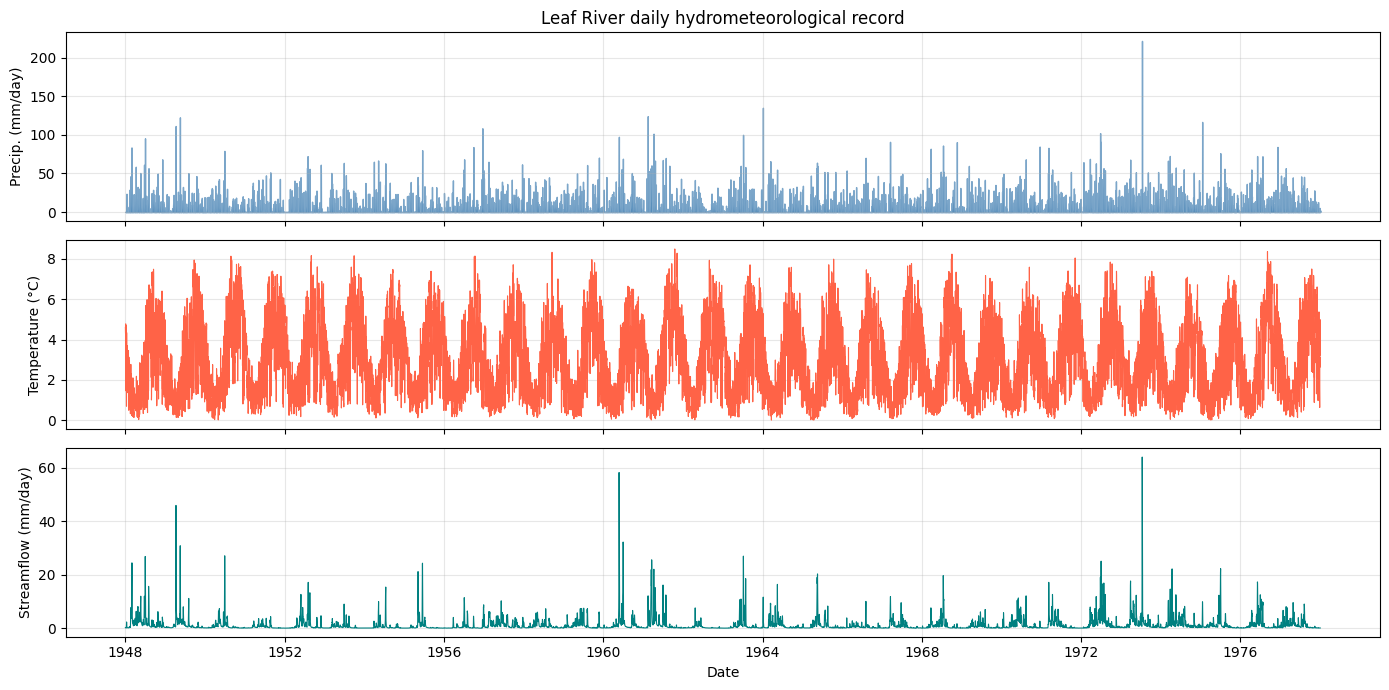

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(df.index, df['Precipitation'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Precip. (mm/day)')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['Temperature'], color='tomato', lw=0.8)
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(alpha=0.3)

axes[2].plot(df.index, df['Streamflow'], color='teal', lw=0.8)
axes[2].set_ylabel('Streamflow (mm/day)')
axes[2].set_xlabel('Date')
axes[2].grid(alpha=0.3)

axes[0].set_title('Leaf River daily hydrometeorological record')
plt.tight_layout()
plt.show()

## 2. Train / validation / test split and normalisation

For time series we **never shuffle**: past cannot be used to predict past. We use a strict chronological split:

- **Train**: first 60% (warmup for the scaler and model)
- **Validation**: next 20% (hyperparameter selection, early stopping)
- **Test**: final 20% (held out until the very end)

We normalise inputs (P, T) using the **training set statistics only** to avoid data leakage. Streamflow is log-transformed before normalisation because it is strongly right-skewed — this makes the MSE loss scale more evenly across low and high flows.

In [5]:
n = len(df)
n_train = int(0.60 * n)
n_val   = int(0.20 * n)
n_test  = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df   = df.iloc[n_train:n_train + n_val].copy()
test_df  = df.iloc[n_train + n_val:].copy()

print(f"Train: {len(train_df)} days  |  Val: {len(val_df)} days  |  Test: {len(test_df)} days")

# Normalise inputs
input_cols = ['Precipitation', 'Temperature']
scaler_x = StandardScaler()
train_x = scaler_x.fit_transform(train_df[input_cols].values)
val_x   = scaler_x.transform(val_df[input_cols].values)
test_x  = scaler_x.transform(test_df[input_cols].values)

# Log-transform + normalise streamflow
eps = 1e-6  # avoid log(0)
train_q_raw = train_df['Streamflow'].values
val_q_raw   = val_df['Streamflow'].values
test_q_raw  = test_df['Streamflow'].values

train_q_log = np.log(train_q_raw + eps)
q_mean, q_std = train_q_log.mean(), train_q_log.std()
train_q = (train_q_log - q_mean) / q_std
val_q   = (np.log(val_q_raw   + eps) - q_mean) / q_std
test_q  = (np.log(test_q_raw  + eps) - q_mean) / q_std

print(f"\nStreamflow stats (log-norm): mean={train_q.mean():.3f}, std={train_q.std():.3f}")

Train: 6576 days  |  Val: 2192 days  |  Test: 2192 days

Streamflow stats (log-norm): mean=-0.000, std=1.000


## 3. Dataset with lagged lookback window

At each time step $t$, we provide the model with a window of the past `LOOKBACK` days of (P, T) and ask it to predict streamflow at day $t$. This is the **encoder** pattern: the LSTM reads the forcing history and its final hidden state (or last output) encodes the current "catchment state" (soil moisture, snowpack, etc.).

In [6]:
LOOKBACK = 365  # one year of antecedent conditions

class HydrologyDataset(Dataset):
    """
    Returns (X, y) pairs where:
      X: tensor of shape [LOOKBACK, n_features]  — forcing history
      y: scalar  — streamflow at the next time step (t = LOOKBACK)
    """
    def __init__(self, x, q, lookback):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.q = torch.tensor(q, dtype=torch.float32)
        self.lookback = lookback

    def __len__(self):
        return len(self.q) - self.lookback

    def __getitem__(self, idx):
        x_window = self.x[idx : idx + self.lookback]          # [L, F]
        y_target = self.q[idx + self.lookback].unsqueeze(0)   # [1]
        return x_window, y_target

train_ds = HydrologyDataset(train_x, train_q, LOOKBACK)
val_ds   = HydrologyDataset(val_x,   val_q,   LOOKBACK)
test_ds  = HydrologyDataset(test_x,  test_q,  LOOKBACK)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)

xb, yb = next(iter(train_dl))
print(f"Batch shapes — X: {xb.shape}  y: {yb.shape}")

Batch shapes — X: torch.Size([64, 365, 2])  y: torch.Size([64, 1])


## 4. Model definitions

We compare three architectures:

- **MLP baseline** — flattens the full lookback window into a vector; has no notion of time order
- **LSTM** — processes the sequence step by step; the final hidden state drives the prediction
- **GRU** — same structure as LSTM but with fewer parameters

In [7]:
class MLPBaseline(nn.Module):
    def __init__(self, lookback, n_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(lookback * n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        # x: [B, L, F] → flatten → [B, L*F]
        return self.net(x.view(x.size(0), -1))


class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        # x: [B, L, F]
        out, (h, c) = self.lstm(x)
        # Use the hidden state at the last time step
        return self.head(out[:, -1, :])  # [B, 1]


class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=1):
        super().__init__()
        self.gru  = nn.GRU(n_features, hidden, n_layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, h = self.gru(x)
        return self.head(out[:, -1, :])


N_FEATURES = 2  # P, T
HIDDEN     = 64

mlp  = MLPBaseline(LOOKBACK, N_FEATURES, hidden=128).to(device)
lstm = LSTMModel(N_FEATURES, hidden=HIDDEN).to(device)
gru  = GRUModel(N_FEATURES,  hidden=HIDDEN).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"MLP  params: {count_params(mlp):,}")
print(f"LSTM params: {count_params(lstm):,}")
print(f"GRU  params: {count_params(gru):,}")

MLP  params: 101,889
LSTM params: 17,473
GRU  params: 13,121


## 5. Training

In [8]:
def train_model(model, train_dl, val_dl, n_epochs=30, lr=1e-3, patience=8):
    opt      = optim.Adam(model.parameters(), lr=lr)
    loss_fn  = nn.MSELoss()
    history  = {'train': [], 'val': []}
    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        # --- Train ---
        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
        train_loss /= len(train_dl)

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item()
        val_loss /= len(val_dl)

        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs}  train={train_loss:.4f}  val={val_loss:.4f}")

        if epochs_no_improve >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return history

print("Training MLP...")
mlp_hist  = train_model(mlp,  train_dl, val_dl, n_epochs=60)
print("\nTraining LSTM...")
lstm_hist = train_model(lstm, train_dl, val_dl, n_epochs=60)
print("\nTraining GRU...")
gru_hist  = train_model(gru,  train_dl, val_dl, n_epochs=60)

Training MLP...
  Epoch   5/60  train=0.0186  val=0.1015
  Epoch  10/60  train=0.0057  val=0.0903
  Early stop at epoch 11

Training LSTM...
  Epoch   5/60  train=0.0803  val=0.0884
  Epoch  10/60  train=0.0726  val=0.0543
  Epoch  15/60  train=0.0681  val=0.0567
  Early stop at epoch 18

Training GRU...
  Epoch   5/60  train=0.0725  val=0.1028
  Epoch  10/60  train=0.0624  val=0.0854
  Epoch  15/60  train=0.0568  val=0.0699
  Epoch  20/60  train=0.0546  val=0.0991
  Early stop at epoch 21


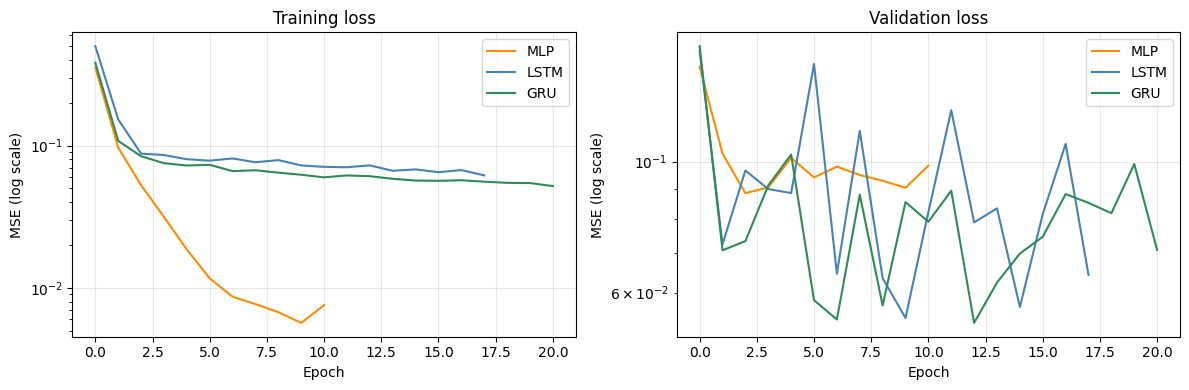

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'MLP': 'darkorange', 'LSTM': 'steelblue', 'GRU': 'seagreen'}

for name, hist in [('MLP', mlp_hist), ('LSTM', lstm_hist), ('GRU', gru_hist)]:
    axes[0].semilogy(hist['train'], label=name, color=colors[name])
    axes[1].semilogy(hist['val'],   label=name, color=colors[name])

for ax, title in zip(axes, ['Training loss', 'Validation loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log scale)')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluation metrics

MSE on normalised log-flow is useful for training, but hydrologists care about two metrics:

**Root Mean Squared Error (RMSE)** on original (mm/day) streamflow:
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^N (\hat{Q}_t - Q_t)^2}$$

**Nash-Sutcliffe Efficiency (NSE)** — measures skill relative to using the observed mean as a predictor:
$$\text{NSE} = 1 - \frac{\sum_{t=1}^N (Q_t - \hat{Q}_t)^2}{\sum_{t=1}^N (Q_t - \bar{Q})^2}$$

| NSE | Interpretation |
|-----|----------------|
| 1.0 | Perfect |
| > 0.75 | Good |
| 0.5 – 0.75 | Satisfactory |
| < 0.5 | Unsatisfactory |
| ≤ 0 | Worse than climatology |

In [10]:
def predict(model, dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            xb = xb.to(device)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds).squeeze()

def denorm_streamflow(q_norm):
    """Undo log-normalisation to get mm/day."""
    return np.exp(q_norm * q_std + q_mean) - eps

def calc_metrics(true, pred):
    rmse = np.sqrt(np.mean((true - pred) ** 2))
    nse  = 1 - np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2)
    pbias = 100 * (np.sum(pred - true) / np.sum(true))
    return {'RMSE': rmse, 'NSE': nse, 'PBias (%)': pbias}

# Ground truth (original scale)
test_true = test_q_raw[LOOKBACK:]

results = {}
for name, model in [('MLP', mlp), ('LSTM', lstm), ('GRU', gru)]:
    pred_norm = predict(model, test_dl)
    pred_mm   = denorm_streamflow(pred_norm)
    pred_mm   = np.clip(pred_mm, 0, None)  # streamflow is non-negative
    results[name] = {'pred': pred_mm, 'metrics': calc_metrics(test_true, pred_mm)}

print("Test set performance:")
print(f"{'Model':<6} {'RMSE (mm/d)':>14} {'NSE':>8} {'PBias (%)':>12}")
print('-' * 44)
for name, r in results.items():
    m = r['metrics']
    print(f"{name:<6} {m['RMSE']:>14.4f} {m['NSE']:>8.4f} {m['PBias (%)']:>12.2f}")

Test set performance:
Model     RMSE (mm/d)      NSE    PBias (%)
--------------------------------------------
MLP           13.8020 -16.2546        16.37
LSTM           1.5255   0.7892       -10.95
GRU            1.1843   0.8730        -8.56


## 7. Hydrograph comparison

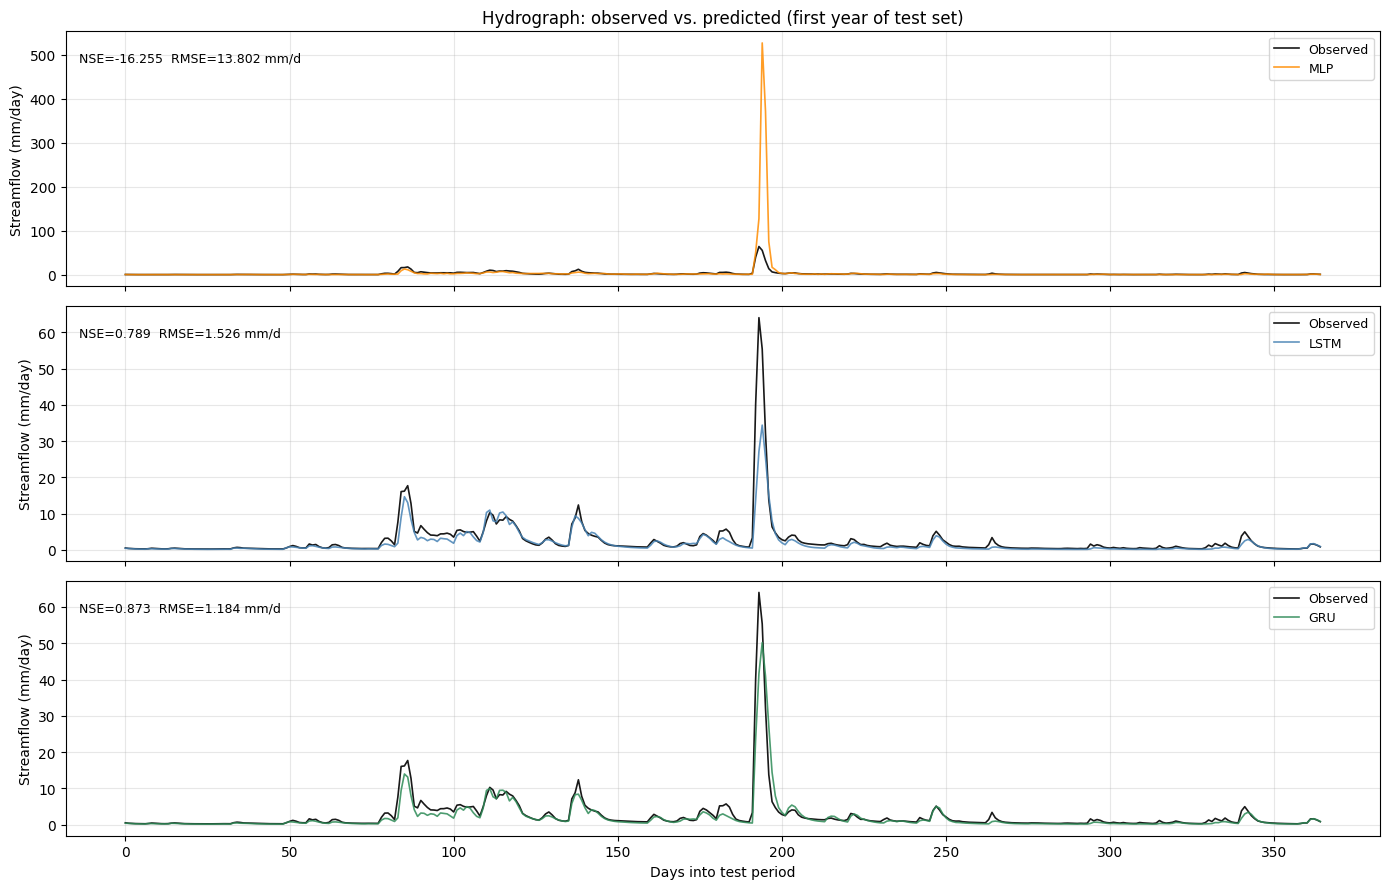

In [11]:
# Plot one year of the test period
plot_days = 365
t_axis = np.arange(plot_days)
obs = test_true[:plot_days]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

plot_configs = [
    ('MLP',  'darkorange'),
    ('LSTM', 'steelblue'),
    ('GRU',  'seagreen'),
]

for ax, (name, color) in zip(axes, plot_configs):
    pred = results[name]['pred'][:plot_days]
    m    = results[name]['metrics']
    ax.plot(t_axis, obs,  color='black', lw=1.2, label='Observed', alpha=0.9)
    ax.plot(t_axis, pred, color=color,   lw=1.2, label=name, alpha=0.85)
    ax.set_ylabel('Streamflow (mm/day)')
    ax.legend(loc='upper right', fontsize=9)
    ax.text(0.01, 0.92,
            f"NSE={m['NSE']:.3f}  RMSE={m['RMSE']:.3f} mm/d",
            transform=ax.transAxes, fontsize=9, va='top')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Days into test period')
axes[0].set_title('Hydrograph: observed vs. predicted (first year of test set)')
plt.tight_layout()
plt.show()

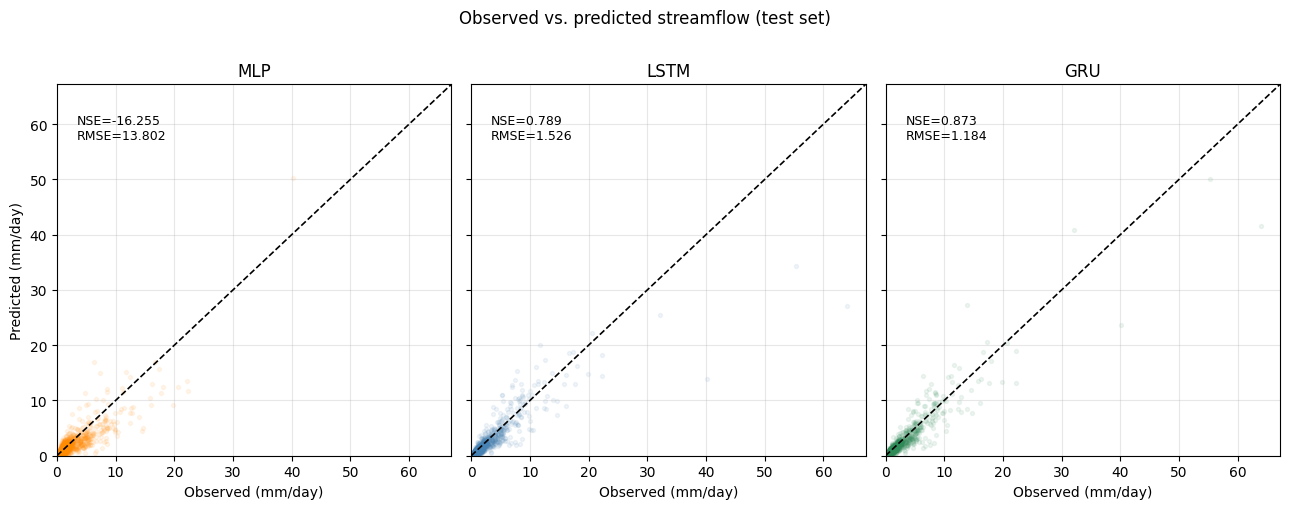

In [14]:
# Scatter plots (observed vs. predicted)
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharex=True, sharey=True)

max_q = test_true.max() * 1.05
for ax, (name, color) in zip(axes, plot_configs):
    pred = results[name]['pred']
    m    = results[name]['metrics']
    ax.scatter(test_true, pred, alpha=0.08, s=8, color=color)
    ax.plot([0, max_q], [0, max_q], 'k--', lw=1.2, label='1:1 line')
    ax.set_xlim(0, max_q)
    ax.set_ylim(0, max_q)
    ax.set_title(name)
    ax.set_xlabel('Observed (mm/day)')
    ax.text(0.05, 0.92,
            f"NSE={m['NSE']:.3f}\nRMSE={m['RMSE']:.3f}",
            transform=ax.transAxes, fontsize=9, va='top')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Predicted (mm/day)')
plt.suptitle('Observed vs. predicted streamflow (test set)', y=1.01)
plt.tight_layout()
plt.show()

## 8. What has the LSTM learned?

### Effect of lookback length

How much memory does the catchment actually need? We retrain a lightweight LSTM for multiple lookback windows and compare NSE.

  lookback=7...   Epoch   5/40  train=0.4182  val=0.3641
  Epoch  10/40  train=0.4124  val=0.3739
  Early stop at epoch 10
NSE=0.488
  lookback=14...   Epoch   5/40  train=0.3203  val=0.2988
  Epoch  10/40  train=0.3062  val=0.2920
  Epoch  15/40  train=0.3007  val=0.2793
  Early stop at epoch 19
NSE=0.553
  lookback=30...   Epoch   5/40  train=0.1955  val=0.1946
  Epoch  10/40  train=0.1779  val=0.1771
  Epoch  15/40  train=0.1714  val=0.1793
  Epoch  20/40  train=0.1672  val=0.1510
  Epoch  25/40  train=0.1572  val=0.1827
  Epoch  30/40  train=0.1530  val=0.1976
  Early stop at epoch 32
NSE=0.706
  lookback=60...   Epoch   5/40  train=0.1221  val=0.1009
  Epoch  10/40  train=0.1099  val=0.1243
  Early stop at epoch 11
NSE=0.719
  lookback=120...   Epoch   5/40  train=0.0889  val=0.1199
  Epoch  10/40  train=0.0788  val=0.0760
  Early stop at epoch 14
NSE=0.750
  lookback=180...   Epoch   5/40  train=0.0916  val=0.0857
  Epoch  10/40  train=0.0787  val=0.0923
  Early stop at epoch 13


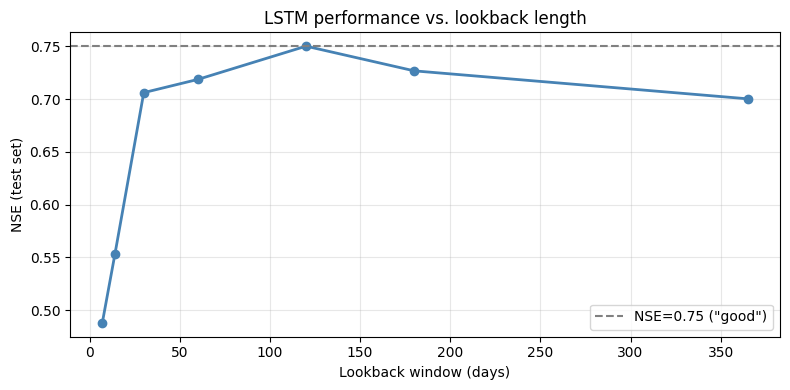

In [13]:
lookback_values = [7, 14, 30, 60, 120, 180, 365]
nse_by_lookback = {}

for lb in lookback_values:
    print(f"  lookback={lb}...", end=' ')
    ds_tr = HydrologyDataset(train_x, train_q, lb)
    ds_vl = HydrologyDataset(val_x,   val_q,   lb)
    ds_te = HydrologyDataset(test_x,  test_q,  lb)
    dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
    dl_vl = DataLoader(ds_vl, batch_size=256)
    dl_te = DataLoader(ds_te, batch_size=256)

    m = LSTMModel(N_FEATURES, hidden=32).to(device)
    _ = train_model(m, dl_tr, dl_vl, n_epochs=40, patience=6)

    pred_norm = predict(m, dl_te)
    pred_mm   = np.clip(denorm_streamflow(pred_norm), 0, None)
    true_mm   = test_q_raw[lb:]
    nse       = calc_metrics(true_mm, pred_mm)['NSE']
    nse_by_lookback[lb] = nse
    print(f"NSE={nse:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(nse_by_lookback.keys()), list(nse_by_lookback.values()),
        marker='o', color='steelblue', lw=2)
ax.axhline(0.75, color='gray', ls='--', label='NSE=0.75 ("good")')
ax.set_xlabel('Lookback window (days)')
ax.set_ylabel('NSE (test set)')
ax.set_title('LSTM performance vs. lookback length')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Examining hidden state dynamics

Let's pass the test forcing through the trained LSTM and inspect the hidden state. If the LSTM has learned something physical, we expect the hidden state to respond to precipitation events and decay slowly — mimicking soil moisture.

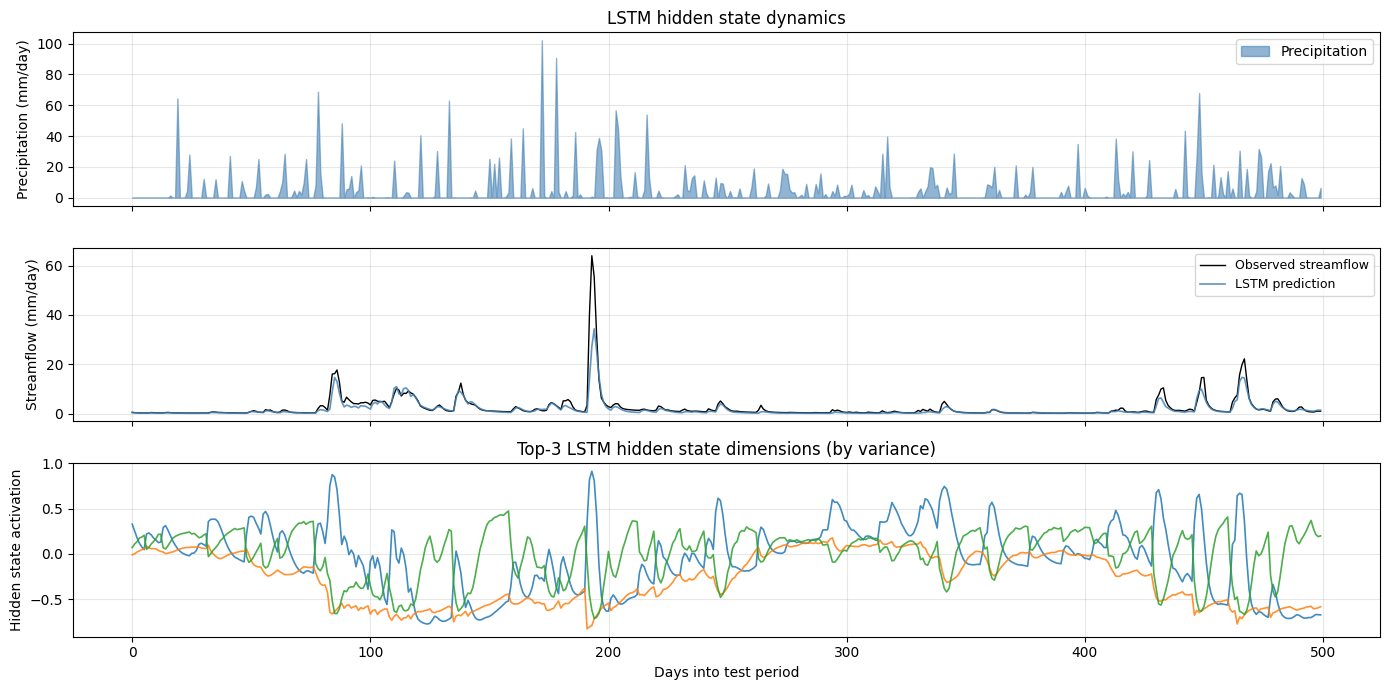

In [15]:
# Extract hidden states over a stretch of the test set
lstm.eval()
n_show = 500

# Feed the full lookback prefix + n_show steps
x_probe = torch.tensor(test_x[:LOOKBACK + n_show], dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    all_out, _ = lstm.lstm(x_probe)  # [1, T, H]

hidden_seq = all_out[0, LOOKBACK:, :].cpu().numpy()  # [n_show, H]

# Pick the 3 dimensions with highest variance
top3 = np.argsort(hidden_seq.var(axis=0))[::-1][:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(range(n_show), test_x[:n_show, 0] * scaler_x.scale_[0] + scaler_x.mean_[0],
                     color='steelblue', alpha=0.6, label='Precipitation')
axes[0].set_ylabel('Precipitation (mm/day)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(test_true[:n_show], color='black', lw=1, label='Observed streamflow')
axes[1].plot(results['LSTM']['pred'][:n_show], color='steelblue', lw=1.2,
             label='LSTM prediction', alpha=0.85)
axes[1].set_ylabel('Streamflow (mm/day)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(hidden_seq[:, top3], lw=1.2, alpha=0.85)
axes[2].set_ylabel('Hidden state activation')
axes[2].set_xlabel('Days into test period')
axes[2].set_title('Top-3 LSTM hidden state dimensions (by variance)')
axes[2].grid(alpha=0.3)

axes[0].set_title('LSTM hidden state dynamics')
plt.tight_layout()
plt.show()

## 9. Summary

| Concept | Key point |
|---------|----------|
| **Lagged lookback** | LSTM reads the last $L$ days of (P, T); the final hidden state encodes catchment state |
| **Log-transform** | Normalises skewed streamflow distribution; makes MSE loss meaningful across flow magnitudes |
| **Chronological split** | No shuffling — future data must never appear in training |
| **NSE** | Standard hydrology skill score: NSE > 0.75 is "good"; NSE ≤ 0 is worse than climatology |
| **Lookback sensitivity** | NSE typically increases with lookback up to ~60–180 days; catchment memory is finite |
| **Hidden state** | Responds to precipitation events and decays — a learned proxy for soil moisture |